Using NREL 500m wave model, create site level dataframe for metrics like mean wave height and 90th percentile of wave height. 

In [1]:
import h5pyd
import h5py
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import haversine
from haversine import haversine, Unit
import numpy as np
from datetime import datetime

In [2]:
sites = pd.read_csv('C:/Users/sarah/Documents/GitHub/ORKA_StatusReport_FollowupPaper/StatusReport_FollowupPaper_Data/MasterSiteList_FollowupPaper.csv')
sites = sites.iloc[0:15,0:8]

In [4]:
#read in the file and get variables as their own.... arrays
#takes about 3 min
#Just going to use 2013-2022 to help standardardize the time over which our variables are being drawn

f = h5py.File('C:/Users/sarah/Desktop/ORKA/Data/NRELWaveData/WestCoast_wave_2013_clipped.h5', 'r')
list(f.keys())
coords = f["coordinates"]
wp = f["omni-directional_wave_power"]
sig = f["significant_wave_height"]
time = f["time_index"]
time = time[:].astype('str')
lat = coords[:,0]
lon = coords[:,1]
#Ok so sig is 2920 arrays with 76391 entries into each array. Each array is a time point so each entry into that array is a 
# moment in space and time 

df = pd.DataFrame(sig[:])
df.replace([-9.0], np.nan, inplace=True)
df

f14 = h5py.File('C:/Users/sarah/Desktop/ORKA/Data/NRELWaveData/WestCoast_wave_2014_clipped.h5', 'r')
time14 = f14["time_index"]
time14 = time14[:].astype('str')
time = np.append(time,time14)
sig14 = f14["significant_wave_height"]
df14 = pd.DataFrame(sig14[:])
df14.replace([-9.0], np.nan, inplace=True)
df = pd.concat([df, df14])

f15 = h5py.File('C:/Users/sarah/Desktop/ORKA/Data/NRELWaveData/WestCoast_wave_2015_clipped.h5', 'r')
time15 = f15["time_index"]
time15 = time15[:].astype('str')
time = np.append(time,time15)
sig15 = f15["significant_wave_height"]
df15 = pd.DataFrame(sig15[:])
df15.replace([-9.0], np.nan, inplace=True)
df = pd.concat([df, df15])

f16 = h5py.File('C:/Users/sarah/Desktop/ORKA/Data/NRELWaveData/WestCoast_wave_2016_clipped.h5', 'r')
time16 = f16["time_index"]
time16 = time16[:].astype('str')
time = np.append(time,time16)
sig16 = f16["significant_wave_height"]
df16 = pd.DataFrame(sig16[:])
df16.replace([-9.0], np.nan, inplace=True)
df = pd.concat([df, df16])

f17 = h5py.File('C:/Users/sarah/Desktop/ORKA/Data/NRELWaveData/WestCoast_wave_2017_clipped.h5', 'r')
time17 = f17["time_index"]
time17 = time17[:].astype('str')
time = np.append(time,time17)
sig17 = f17["significant_wave_height"]
df17 = pd.DataFrame(sig17[:])
df17.replace([-9.0], np.nan, inplace=True)
df = pd.concat([df, df17])

f18 = h5py.File('C:/Users/sarah/Desktop/ORKA/Data/NRELWaveData/WestCoast_wave_2018_clipped.h5', 'r')
time18 = f18["time_index"]
time18 = time18[:].astype('str')
time = np.append(time,time18)
sig18 = f18["significant_wave_height"]
df18 = pd.DataFrame(sig18[:])
df18.replace([-9.0], np.nan, inplace=True)
df = pd.concat([df, df18])

f19 = h5py.File('C:/Users/sarah/Desktop/ORKA/Data/NRELWaveData/WestCoast_wave_2019_clipped.h5', 'r')
time19 = f19["time_index"]
time19 = time19[:].astype('str')
time = np.append(time,time19)
sig19 = f19["significant_wave_height"]
df19 = pd.DataFrame(sig19[:])
df19.replace([-9.0], np.nan, inplace=True)
df = pd.concat([df, df19])

f20 = h5py.File('C:/Users/sarah/Desktop/ORKA/Data/NRELWaveData/WestCoast_wave_2020_clipped.h5', 'r')
time20 = f20["time_index"]
time20 = time20[:].astype('str')
time = np.append(time,time20)
sig20 = f20["significant_wave_height"]
df20 = pd.DataFrame(sig20[:])
df20.replace([-9.0], np.nan, inplace=True)
df = pd.concat([df, df20])
df.shape

(23376, 76391)

In [6]:
#Ok going to take the mean/90th P across each column (location) over the 8 years of data 
#Then in the next code block, find which are closest to our sampling locations
#This is a bit of a reversed process for how it is done with the ROMs models data.
#takes about 1 minute
df2 = df.dropna(axis=1, how='all')
means = df2.mean(axis = 0)
means = pd.DataFrame(means, columns = ["Mean"])
p90 = df2.quantile(q = 0.9,axis = 0)
p90 = pd.DataFrame(p90)
p90.columns = ["P90"]

#ok merge with coordinates in a summary data frame
coords_df = pd.DataFrame(coords[:], columns = ["Lat","Lon"])
summary = pd.merge(coords_df, means, left_index = True, right_index = True)
summary = pd.merge(summary, p90, left_index = True, right_index = True)
summary.reset_index(drop = True, inplace = True)


In [7]:
%%time
#ID which Wave model grid cells are closest to our sampling locations
p90 = [None] * len(sites)
mean = [None] * len(sites)
lat = sites.SiteLatitude[0]
lon = sites.SiteLongitude[0]
site = (lat, lon)
def hav_dist(row):
    site2 = (row["Lat"],row["Lon"])
    return haversine(site,site2)
dist = summary.apply(hav_dist, axis = 1)
index1 = dist[dist == dist.min()].index
closest = summary.iloc[index1,:]
p90[0] = closest["P90"].values[0]
mean[0] = closest["Mean"].values[0]
for i in range(1,len(sites)): 
    site = (sites.SiteLatitude[i], sites.SiteLongitude[i])
    dist = summary.apply(hav_dist, axis = 1)
    index1 = dist[dist == dist.min()].index
    closest = summary.iloc[index1,:]
    p90[i] = closest["P90"].values[0]
    mean[i] = closest["Mean"].values[0]
print(p90)
print(mean)
#then adding these site-level metrics to a site-level dataframe as columns
sites["Waves_P90"] = p90
sites["Waves_Mean"] = mean

CPU times: total: 2.36 s
Wall time: 2.55 s


OK Now how would I get p90/mean for winter vs. summer wave height....

In [11]:
#Ok get the time into datetime format and then you can look for the indices you want
#Time is 29224 long and the df2 dataframe has 29224 rows. So you'll filter on rows
time = time[:].astype('datetime64')
times_df = pd.DataFrame(time)
times_df["months"] = times_df[0].dt.month
summer_ind = np.where((times_df.months >= 4) & (times_df.months <=9))
winter_ind = np.where((times_df.months < 4) | (times_df.months >9))

In [12]:
#Taking several minutes about 10:27 - 10:32
winter_df = df2.iloc[winter_ind[0], :]
summer_df = df2.iloc[summer_ind[0],:]
winter_means = winter_df.mean(axis = 0)
winter_means = pd.DataFrame(winter_means, columns = ["Mean"])
summer_means = summer_df.mean(axis = 0)
summer_means = pd.DataFrame(summer_means, columns = ["Mean"])
winter_p90 = winter_df.quantile(q = 0.9,axis = 0)
winter_p90 = pd.DataFrame(winter_p90)
winter_p90.columns = ["P90"]
summer_p90 = summer_df.quantile(q = 0.9,axis = 0)
summer_p90 = pd.DataFrame(summer_p90)
summer_p90.columns = ["P90"]

#ok merge with coordinates in two summary data frames specific to winter and summer values. 
coords_df = pd.DataFrame(coords[:], columns = ["Lat","Lon"])
winter_summary = pd.merge(coords_df, winter_means, left_index = True, right_index = True)
winter_summary = pd.merge(winter_summary, winter_p90, left_index = True, right_index = True)
winter_summary.reset_index(drop = True, inplace = True)
summer_summary = pd.merge(coords_df, summer_means, left_index = True, right_index = True)
summer_summary = pd.merge(summer_summary, summer_p90, left_index = True, right_index = True)
summer_summary.reset_index(drop = True, inplace = True)


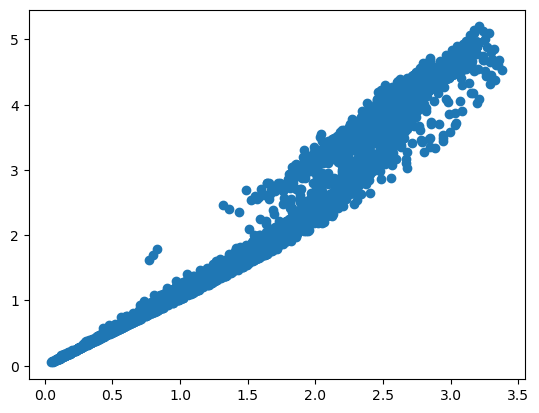

In [13]:
plt.scatter(winter_summary.Mean, winter_summary.P90)

In [14]:
%%time

#Summer values for each site
#Takes A little under a minute
p90 = [None] * len(sites)
mean = [None] * len(sites)
lat = sites.SiteLatitude[0]
lon = sites.SiteLongitude[0]
site = (lat, lon)
def hav_dist(row):
    site2 = (row["Lat"],row["Lon"])
    return haversine(site,site2)
dist = summer_summary.apply(hav_dist, axis = 1)
index1 = dist[dist == dist.min()].index
closest = summer_summary.iloc[index1,:]
p90[0] = closest["P90"].values[0]
mean[0] = closest["Mean"].values[0]

for i in range(1,len(sites)): 
    site = (sites.SiteLatitude[i], sites.SiteLongitude[i])
    dist = summer_summary.apply(hav_dist, axis = 1)
    index1 = dist[dist == dist.min()].index
    closest = summer_summary.iloc[index1,:]
    p90[i] = closest["P90"].values[0]
    mean[i] = closest["Mean"].values[0]
print(p90)
print(mean)
#then adding these summer specific site-level metrics to a site-level dataframe as columns
sites["Summer_Waves_P90"] = p90
sites["Summer_Waves_Mean"] = mean

[np.float64(0.8052240192890167), np.float64(2.310783052444458), np.float64(2.530031061172485), np.float64(1.2550780057907103), np.float64(0.9098620235919952), np.float64(2.3317409515380856), np.float64(2.1319719791412353), np.float64(2.8302480697631833), np.float64(1.8737879514694213), np.float64(1.9336179852485655), np.float64(1.7679789781570434), np.float64(1.7540859818458554), np.float64(1.6481990337371826), np.float64(1.5226159691810608), np.float64(1.0360479712486268)]
[np.float32(0.6604565), np.float32(1.5670614), np.float32(1.8161833), np.float32(1.0553837), np.float32(0.8106263), np.float32(1.7101454), np.float32(1.6897745), np.float32(2.0272627), np.float32(1.6620595), np.float32(1.2845827), np.float32(1.2274374), np.float32(1.1906464), np.float32(1.5606824), np.float32(1.1624625), np.float32(0.8806667)]
CPU times: total: 26.3 s
Wall time: 27.7 s


In [15]:
%%time

#Winter values for each site
#Takes A little under a minute
p90 = [None] * len(sites)
mean = [None] * len(sites)
lat = sites.SiteLatitude[0]
lon = sites.SiteLongitude[0]
site = (lat, lon)
def hav_dist(row):
    site2 = (row["Lat"],row["Lon"])
    return haversine(site,site2)
dist = winter_summary.apply(hav_dist, axis = 1)
index1 = dist[dist == dist.min()].index
closest = winter_summary.iloc[index1,:]
p90[0] = closest["P90"].values[0]
mean[0] = closest["Mean"].values[0]

for i in range(1,len(sites)): 
    site = (sites.SiteLatitude[i], sites.SiteLongitude[i])
    dist = winter_summary.apply(hav_dist, axis = 1)
    index1 = dist[dist == dist.min()].index
    closest = winter_summary.iloc[index1,:]
    p90[i] = closest["P90"].values[0]
    mean[i] = closest["Mean"].values[0]
print(p90)
print(mean)
#then adding these winter specific site-level metrics to a site-level dataframe as columns
sites["Winter_Waves_P90"] = p90
sites["Winter_Waves_Mean"] = mean

[np.float64(1.0528190016746521), np.float64(3.8313679218292243), np.float64(3.3103870630264285), np.float64(1.489903998374939), np.float64(1.0591870307922364), np.float64(3.9507999420166016), np.float64(2.6931350946426393), np.float64(3.7063229560852053), np.float64(2.1457839250564574), np.float64(3.211152076721192), np.float64(3.363491106033325), np.float64(3.136997985839844), np.float64(1.708067035675049), np.float64(2.008721995353699), np.float64(1.3788349986076356)]
[np.float32(0.82934815), np.float32(2.57744), np.float32(2.5639298), np.float32(1.2762368), np.float32(0.9277009), np.float32(2.5819802), np.float32(2.186822), np.float32(2.8590186), np.float32(1.8858813), np.float32(2.1389036), np.float32(2.0826325), np.float32(2.009583), np.float32(1.6410629), np.float32(1.5434848), np.float32(1.1025183)]
CPU times: total: 26.5 s
Wall time: 28.1 s


In [17]:
#Ok let save this dataset for later use in linear regressions
sites.to_csv("C:/Users/sarah/Documents/GitHub/ORKA_StatusReport_FollowupPaper/StatusReport_FollowupPaper_Data/MasterSites_WithWaveMetrics_20132020.csv")